# KPI Mensili della Rete Telecom: Barre di Utilizzo Dati con Linee ARPU e Abbandono (PROC GBARLINE)

## Sintesi esecutiva

Questo notebook usa **PROC GBARLINE** per combinare un grafico a barre verticali dell'utilizzo mensile di dati mobili con grafici a linee sovrapposti di ARPU, abbandono e ticket di supporto — la classica dashboard KPI a "due assi" che un analista telecom costruisce per capire se l'aumento dell'utilizzo si traduce davvero in ricavi e fidelizzazione. Genera record sintetici per abbonato inline, quindi utilizza le istruzioni BAR e LINE con sottogruppi, assi destri personalizzati, simboli di riferimento e legende.

## Fonti dei dati

**Dataset: `telco_kpi`** — record sintetici per abbonato-mese (4 mesi x 3 livelli di piano x 8 abbonati = 96 righe), generati inline con `call streaminit(20260531)`. Il panel è mantenuto a 96 righe così da rientrare comodamente nel limite di 100 osservazioni della modalità senza licenza, lasciando ogni mese e livello di piano completamente popolato.

| Variabile | Tipo | Descrizione |
|----------|------|--------------|
| `month`  | Char | Etichetta del mese di calendario (Gen–Apr) |
| `plan`   | Char | Livello di piano: Prepagato, Postpagato, Famiglia |
| `data_gb`| Num  | Dati mobili consumati mensilmente, in GB (distribuzione gamma, con un lieve incremento stagionale e crescita lenta) |
| `arpu`   | Num  | Ricavo medio per utente, in USD (aumenta con il livello di piano e nel corso dei mesi) |
| `churn`  | Num  | Flag mensile di abbandono (0/1, Bernoulli; più alto all'inizio del periodo e sui livelli più economici) |
| `tickets`| Num  | Ticket di supporto aperti (conteggio Poisson) |

# KPI Mensili della Rete Telecom con PROC GBARLINE

Gli operatori telecom vivono e muoiono su una manciata di KPI mensili: quanti **dati** consumano gli abbonati, l'**ARPU** (ricavo medio per utente) che quel consumo genera, quanti clienti **abbandonano**, e il carico di **ticket di supporto** dietro a tutto questo. Queste metriche vivono su scale molto diverse — gigabyte, dollari e piccoli conteggi — quindi rappresentarle su un unico asse di risposta ne nasconde la storia.

`PROC GBARLINE` è costruita esattamente per questo: disegna un grafico a **barre** verticali sull'asse sinistro e sovrappone uno o più grafici a **linee** su un asse destro indipendente. In questo notebook costruiamo una dashboard utilizzo-vs-ricavo, poi aggiungiamo progressivamente sottogruppi a livello di piano, un asse destro personalizzato e sovrapposizioni multi-linea.

## Passo 1 — Generare dati sintetici abbonato-mese

Il passo DATA qui sotto fabbrica un panel realistico: 4 mesi (Gen–Apr) su 3 livelli di piano (Prepagato, Postpagato, Famiglia) con 8 abbonati ciascuno, per 96 righe in totale. Impostiamo il seme del RNG con `call streaminit` per la riproducibilità e estraiamo ogni KPI da una distribuzione appropriata al dominio:

- **Utilizzo dati** da una distribuzione gamma con un lieve incremento stagionale e crescita lenta di mese in mese.
- **ARPU** in aumento con il livello di piano e nel corso dei mesi, con rumore normale.
- **Abbandono** come flag di Bernoulli più alto all'inizio del periodo e sui livelli più economici.
- **Ticket di supporto** come conteggi di Poisson, leggermente più pesanti all'inizio.

Nessun file esterno viene letto — tutto è autocontenuto, e il panel di 96 righe rimane entro il limite di 100 osservazioni della modalità senza licenza così che ogni mese e livello venga renderizzato.

In [1]:
DATI telco_kpi;
    CHIAMARE streaminit(20260531);
    LUNGHEZZA month $3 plan $10;
    VETTORE mname[4] $3 _temporary_
        ('Gen' 'Feb' 'Mar' 'Apr');
    FARE mi = 1 FINO_A 4;
        month = mname[mi];
        /* lieve incremento stagionale e crescita lenta dei dati */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        FARE plan_i = 1 FINO_A 3;
            SE_COND plan_i = 1 ALLORA plan = 'Prepagato';
            ALTRIMENTI SE_COND plan_i = 2 ALLORA plan = 'Postpagato';
            ALTRIMENTI plan = 'Famiglia';
            FARE rep = 1 FINO_A 8;
                /* dati mobili consumati mensilmente (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* ricavo medio per utente ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* flag mensile di abbandono, piu alto a inizio anno */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* ticket di supporto aperti */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                USCITA;
            FINE;
        FINE;
    FINE;
    RIMUOVERE mi plan_i rep season mname:;
ESEGUIRE;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — La dashboard di base: barre di utilizzo + linea ARPU

Questo è il pattern canonico di `GBARLINE`. L'istruzione `BAR` rappresenta l'utilizzo medio mensile di dati (`SUMVAR=data_gb TYPE=mean`), e una singola istruzione `LINE` sovrappone l'ARPU medio sull'asse destro (`STAT=mean TYPE=join`). Attiviamo ODS Graphics e diamo al grafico un titolo su due righe. `COUTLINE=` e `WIDTH=` rifiniscono le barre.

                                           Consumo dati mobili mensile e ARPU                                           
                                     KPI sintetici della rete di telecomunicazioni                                      




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Consumo dati mobili mensile e ARPU.
NOTE: Option TITLE2 changed to KPI sintetici della rete di telecomunicazioni.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


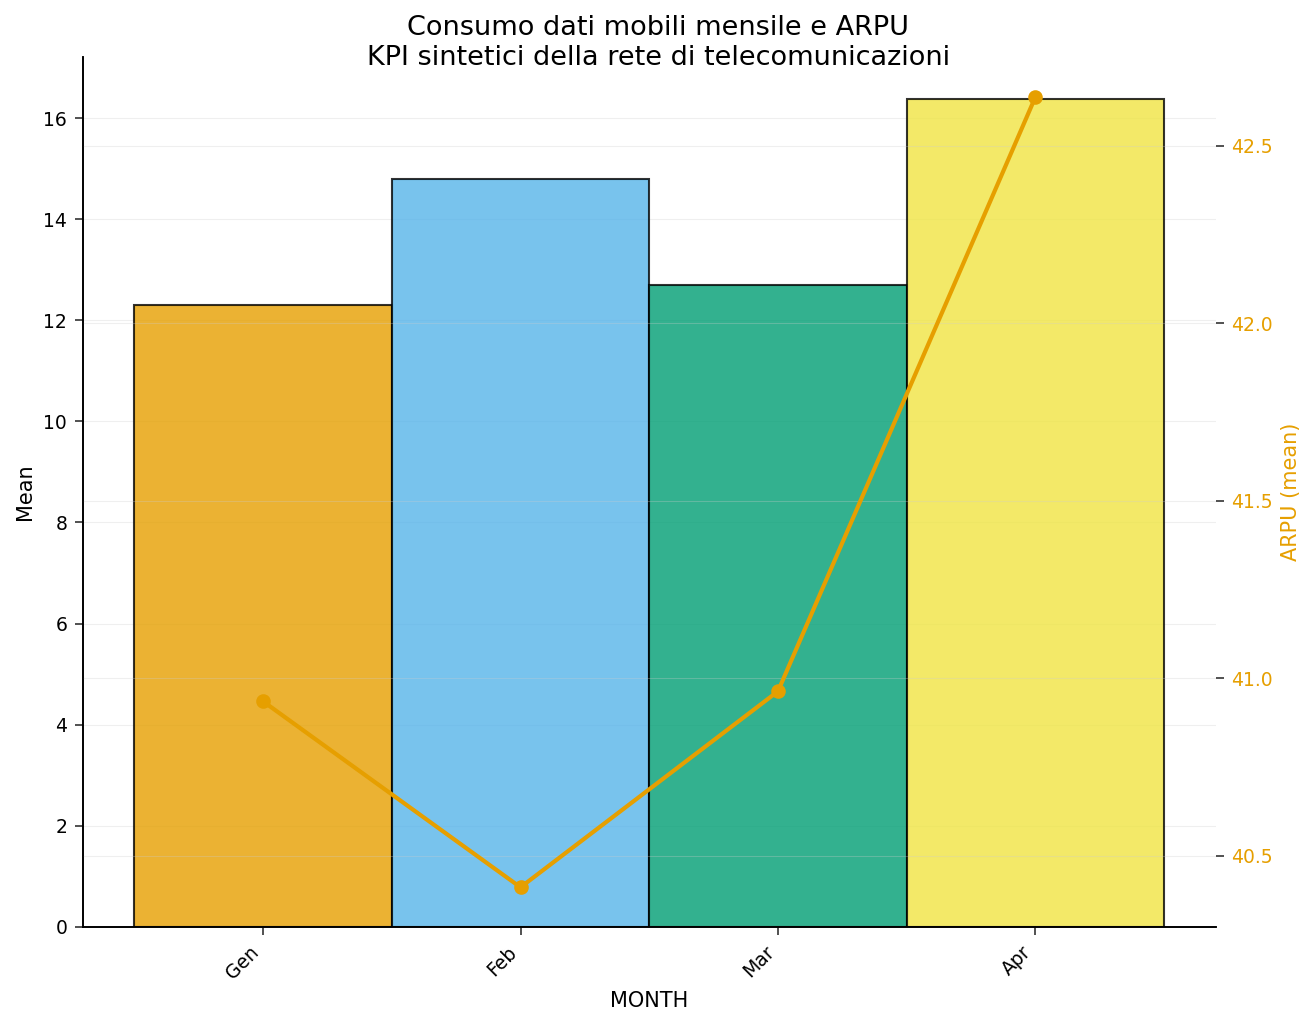

In [2]:
ODS GRAPHICS ON;
TITOLO "Consumo dati mobili mensile e ARPU";
title2 "KPI sintetici della rete di telecomunicazioni";

PROCEDURA gbarline DATI=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
ESEGUIRE;


## Passo 3 — Scomporre l'utilizzo per piano, sovrapporre l'abbandono

Sostituendo `TYPE=mean` con `TYPE=sum` e aggiungendo `SUBGROUP=plan` si impila la barra di ogni mese per livello di piano, così possiamo vedere quale segmento guida il volume totale. La `LINE` sovrapposta ora rappresenta il **conteggio** mensile degli eventi di abbandono come grafico ad aghi (`STAT=sum TYPE=needle`) — picchi verticali che si leggono naturalmente come conteggi di eventi discreti piuttosto che come una tendenza continua.

                                      Volume dati per piano con abbandono mensile                                       
                                     KPI sintetici della rete di telecomunicazioni                                      




NOTE: Option TITLE changed to Volume dati per piano con abbandono mensile.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


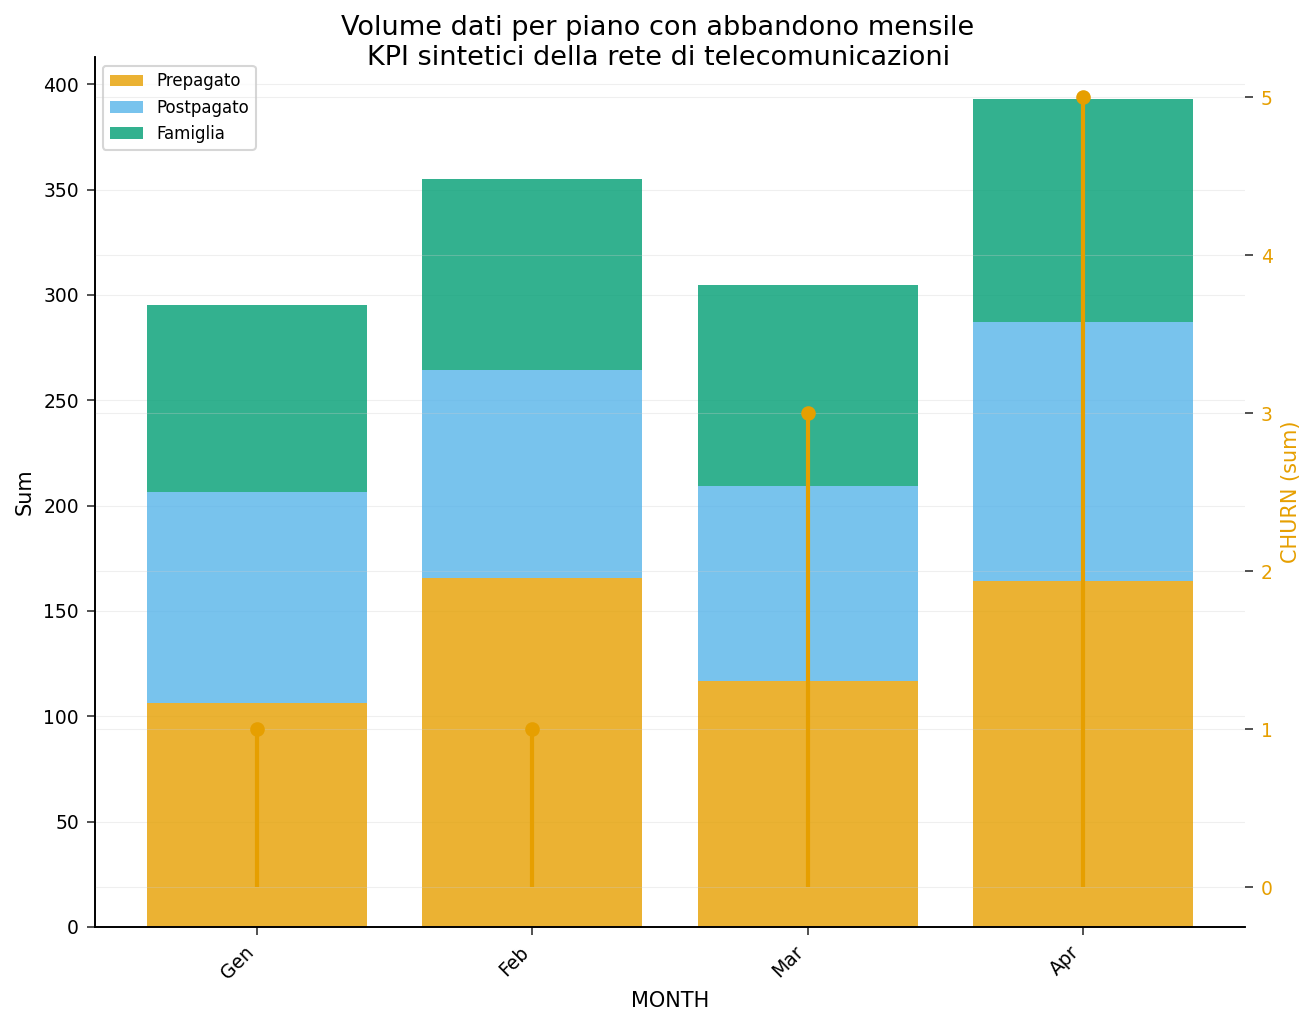

In [3]:
TITOLO "Volume dati per piano con abbandono mensile";

PROCEDURA gbarline DATI=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
ESEGUIRE;


## Passo 4 — Controllare l'asse destro e il marcatore della linea

Per un grafico pronto per la pubblicazione fissiamo l'asse del grafico (destro) a un intervallo fisso con una definizione `AXIS` e lo etichettiamo, poi lo colleghiamo alla linea tramite `RAXIS=axis2`. Una definizione `SYMBOL` dà alla linea ARPU un marcatore rosso a puntini. Mostriamo anche i totali delle barre sopra ogni barra con `OUTSIDE=sum`.

                                     Utilizzo totale (barre) vs ARPU medio (linea)                                      
                                     KPI sintetici della rete di telecomunicazioni                                      




NOTE: Option TITLE changed to Utilizzo totale (barre) vs ARPU medio (linea).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


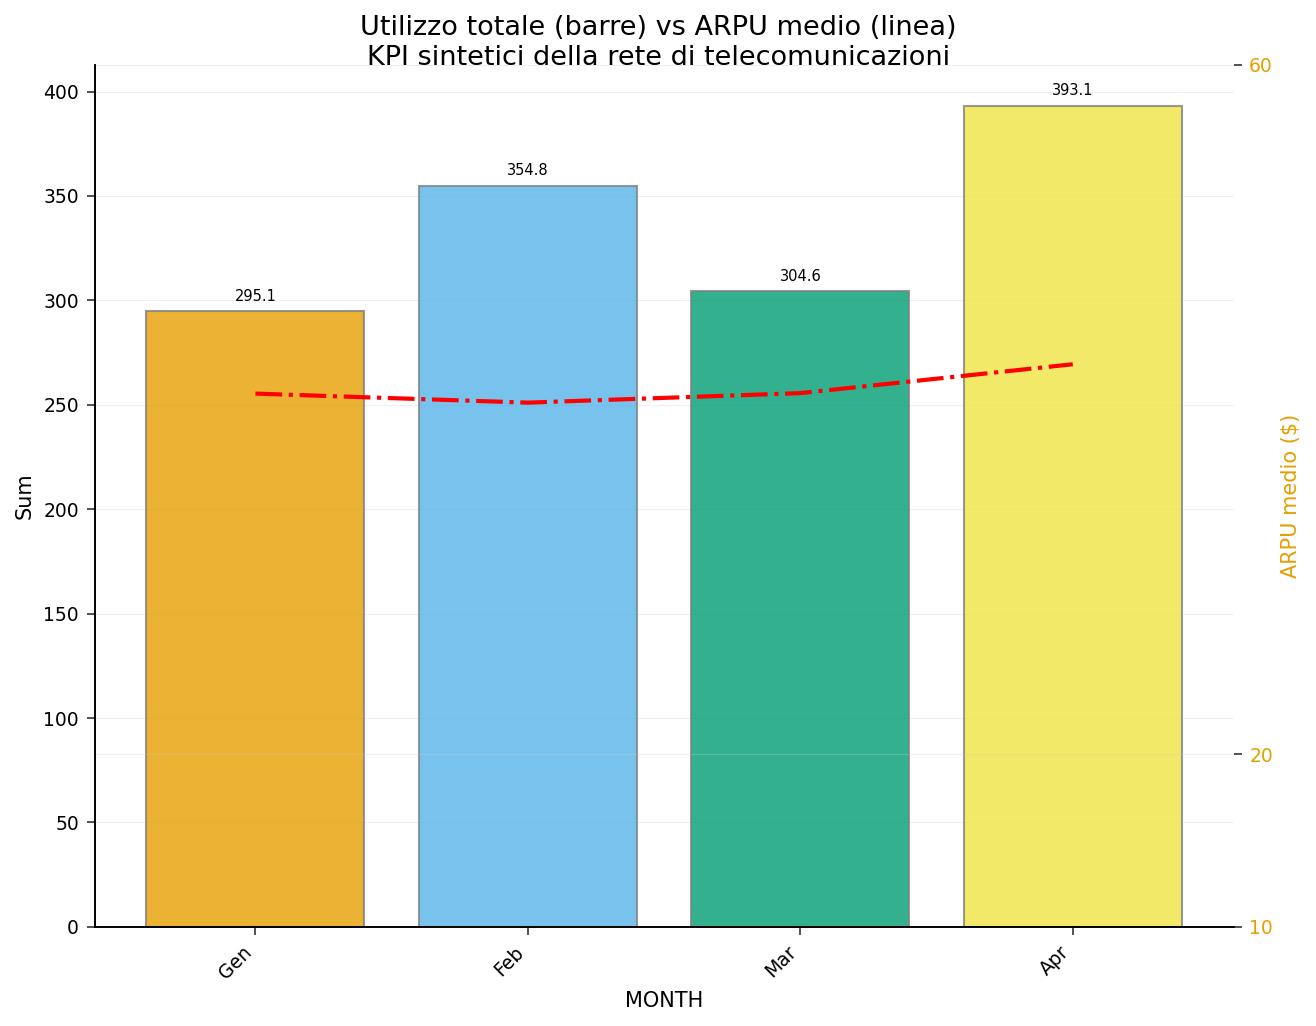

In [4]:
TITOLO "Utilizzo totale (barre) vs ARPU medio (linea)";

PROCEDURA gbarline DATI=telco_kpi;
    axis2 ORDER=(20 FINO_A 60 PER 10) ETICHETTA=("ARPU medio ($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
ESEGUIRE;


## Passo 5 — Sovrapposizioni multi-linea con una legenda personalizzata

`GBARLINE` accetta più di un'istruzione `LINE`, quindi possiamo confrontare due segnali operativi rispetto alle barre di utilizzo contemporaneamente: ticket di supporto medi (`type=join`) e abbandono totale (`type=needle`). Una definizione `LEGEND` posizionata in basso documenta i sottogruppi di piano.

                                       Ticket di supporto e tendenze di abbandono                                       
                                     KPI sintetici della rete di telecomunicazioni                                      




NOTE: Option TITLE changed to Ticket di supporto e tendenze di abbandono.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


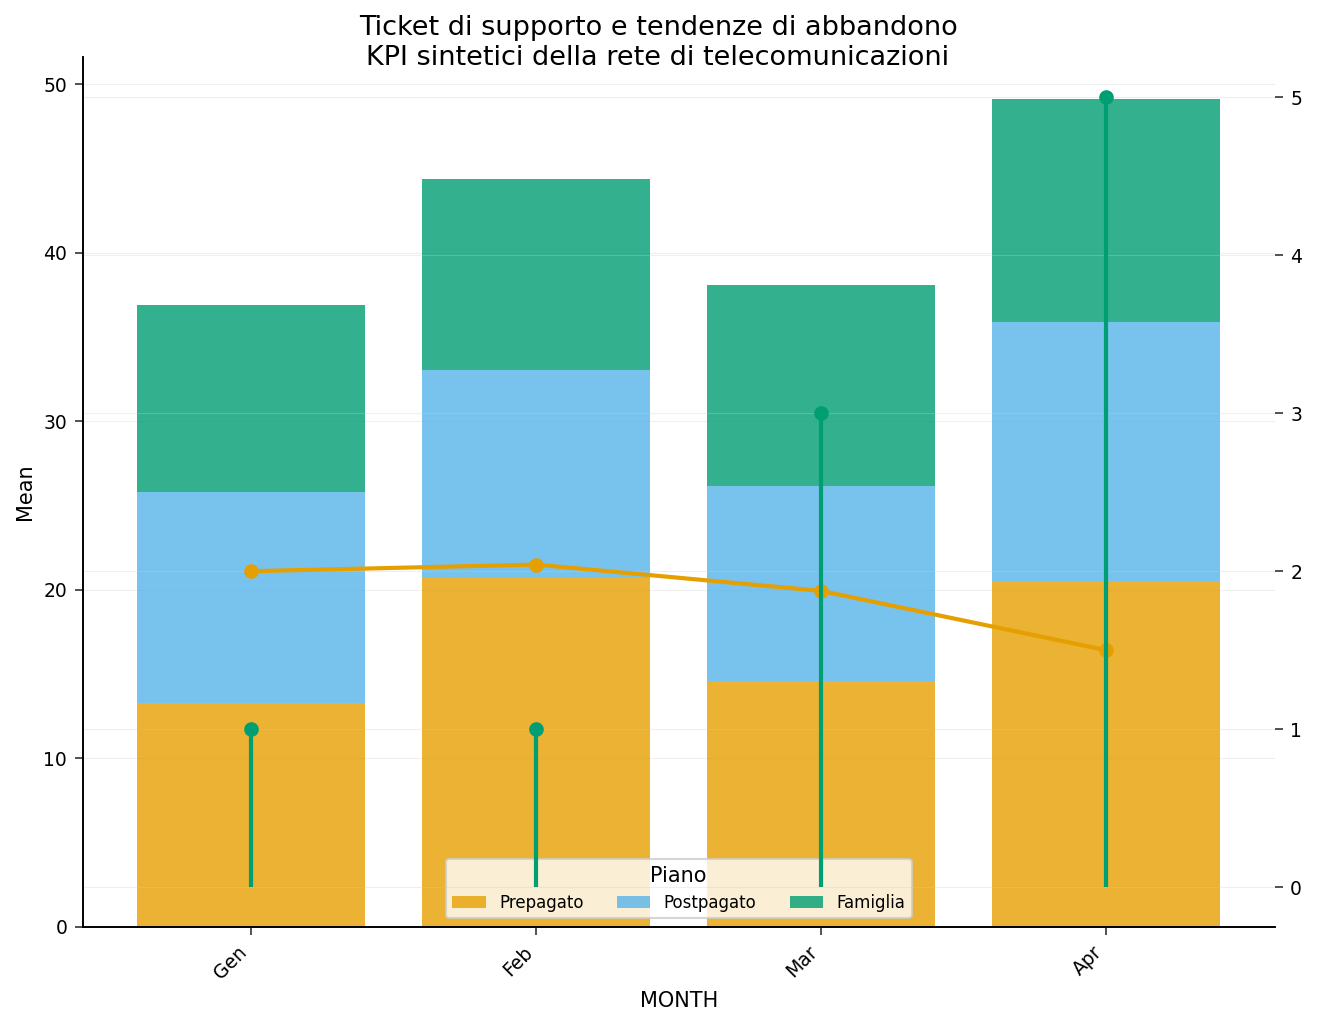

In [5]:
TITOLO "Ticket di supporto e tendenze di abbandono";

PROCEDURA gbarline DATI=telco_kpi;
    legend1 ETICHETTA=("Piano") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
ESEGUIRE;

ODS GRAPHICS OFF;


## Interpretazione dei risultati

Nella finestra Gen–Apr la dashboard racconta una storia telecom coerente. L'**utilizzo dati** (le barre) è irregolare di mese in mese ma con tendenza crescente, con il picco ad **aprile** — l'utilizzo medio sale da circa 12.3 GB a gennaio a 16.4 GB ad aprile (Passo 2), e il volume totale da 295 GB a 393 GB (le etichette `OUTSIDE=sum` nel Passo 4). La **linea ARPU** scende leggermente a febbraio e poi sale fino al suo massimo di aprile vicino a $42.6, quindi l'operatore sta monetizzando sempre di più il consumo aggiuntivo invece di regalarlo — l'asse destro nel Passo 4 è fissato a $20–$60 per mantenere leggibile quel movimento.

Le viste impilate per piano (Passi 3 e 5) rivelano la tensione tra segmenti tipica degli operatori a forte componente prepagata. **Prepagato** (la banda arancione) trasporta più gigabyte in assoluto — circa 553 GB nei quattro mesi contro 415 GB per Postpagato e 380 GB per Famiglia — eppure genera il ricavo medio per utente **più basso** (circa $36, contro $41 per Postpagato e $47 per Famiglia). Gli **aghi di abbandono** confermano dove si trova il rischio di fidelizzazione: gli eventi di abbandono si concentrano sui livelli Prepagato e Postpagato (4 eventi ciascuno nella finestra) e restano più leggeri su Famiglia (2), e crescono verso aprile man mano che la base abbonati e l'utilizzo si espandono.

Il Passo 5 sovrappone il carico operativo su tutto questo: i **ticket di supporto** medi sono un po' più pesanti all'inizio del periodo e si alleggeriscono entro aprile, mentre gli aghi di abbandono raggiungono il picco più tardi — il tipo di segnale che un team di fidelizzazione monitora. Dal punto di vista operativo, la lettura è di concentrare la spesa di fidelizzazione sugli abbonati **Prepagato**, che consumano la fetta di volume dati in crescita più rapida generando però meno ricavi e più abbandono.

`PROC GBARLINE` è lo strumento giusto qui proprio perché mantiene le barre in scala gigabyte e le linee in scala dollari/conteggi su assi indipendenti, permettendo a ogni KPI di essere letto secondo i propri termini pur condividendo lo stesso asse temporale mensile.